In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120

In [25]:
from google.colab import files
uploaded = files.upload()


Saving result_detection.csv to result_detection (3).csv
Saving results_mitigation.csv to results_mitigation (1).csv
Saving revised_original_dataset.csv to revised_original_dataset (3).csv


In [26]:
orig   = pd.read_csv('revised_original_dataset.csv')
detect = pd.read_csv('result_detection.csv')
mitig  = pd.read_csv('results_mitigation_clean.csv')

In [27]:
df = orig.merge(detect[['qid', 'selfcheck_halluc_score', 'is_flagged', 'avg_baseline_sim', 'num_chunks']],
                on='qid', how='left')

df = df.merge(mitig[['qid', 'cove_final_answer', 'cove_status']],
              on='qid', how='left')

print("Full merged shape:", df.shape)
print("Mitigated successfully:", (df['cove_status'] == 'success').sum(), "/", df['is_flagged'].sum())

df.head(2)

Full merged shape: (30, 12)
Mitigated successfully: 27 / 27


,qid,question,category,difficulty,generated_answer,manual_verified_answer,selfcheck_halluc_score,is_flagged,avg_baseline_sim,num_chunks,cove_final_answer,cove_status
0,q01,"Write a function to reverse a string, e.g. 'he...",DSA,easy,def reverse(s):\n return s[::-1],def reverse(s): return s[::-1],0.706384,True,0.293616,1,```python\ndef reverse(s):\n if not isinsta...,success
1,q02,"What is the difference between var, let, and c...",Frontend,easy,"var is function scoped, let and const are bloc...",var: Declares variables with function or globa...,0.824016,True,0.175984,2,```javascript\n// Variable Scope\nvar x = 5; ...,success


In [28]:
flagged_count = df['is_flagged'].sum()
flagged_pct = flagged_count / len(df) * 100

print(f"SelfCheckGPT flagged {flagged_count}/{len(df)} questions ({flagged_pct:.1f}%)")
print(f"Mean hallucination score: {df['selfcheck_halluc_score'].mean():.3f}")
print(f"Median: {df['selfcheck_halluc_score'].median():.3f}")
print(f"Min / Max: {df['selfcheck_halluc_score'].min():.3f} – {df['selfcheck_halluc_score'].max():.3f}")

SelfCheckGPT flagged 27/30 questions (90.0%)
Mean hallucination score: 0.736
Median: 0.719
Min / Max: 0.482 – 1.050


In [29]:
success_rate = (df['cove_status'] == 'success').mean() * 100
print(f"CoVe success rate on flagged: {success_rate:.1f}%")

CoVe success rate on flagged: 90.0%


GRAPHS

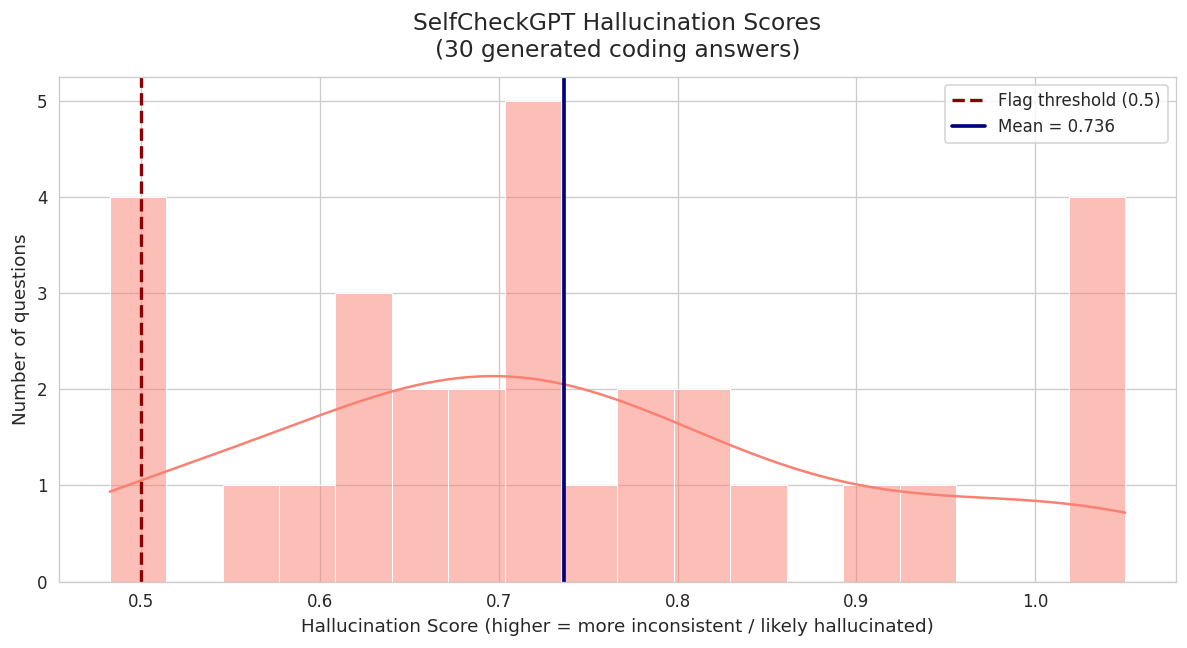

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
plt.figure(figsize=(10, 5.5))
sns.histplot(df['selfcheck_halluc_score'].dropna(), bins=18, kde=True,
             color='salmon', edgecolor='white', linewidth=0.6)
plt.axvline(0.5, color='darkred', linestyle='--', linewidth=2, label='Flag threshold (0.5)')
plt.axvline(df['selfcheck_halluc_score'].mean(), color='navy', linestyle='-', linewidth=2.2,
            label=f'Mean = {df["selfcheck_halluc_score"].mean():.3f}')
plt.title('SelfCheckGPT Hallucination Scores\n(30 generated coding answers)', fontsize=14, pad=12)
plt.xlabel('Hallucination Score (higher = more inconsistent / likely hallucinated)', fontsize=11)
plt.ylabel('Number of questions', fontsize=11)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig_1_scores_distribution.png', dpi=180, bbox_inches='tight')
plt.show()
files.download('fig_1_scores_distribution.png')

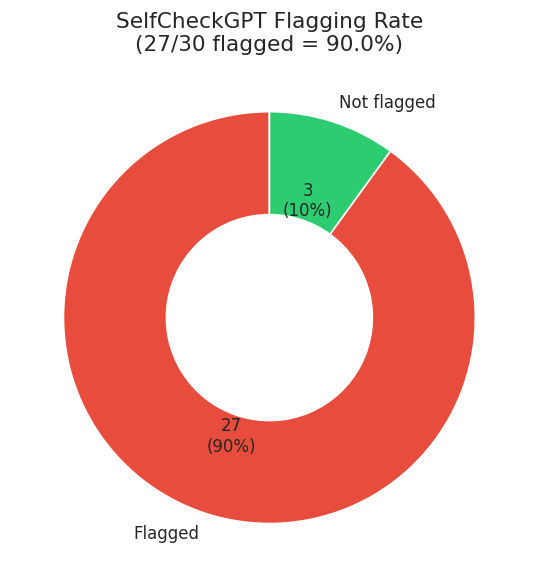

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
Fig, ax = plt.subplots(figsize=(8, 5))

# Pie
wedges, texts, autotexts = ax.pie([flagged_count, len(df)-flagged_count],
                                  labels=['Flagged', 'Not flagged'],
                                  autopct='%1.0f%%', startangle=90, colors=['#e74c3c', '#2ecc71'],
                                  wedgeprops=dict(width=0.5, edgecolor='w'))
ax.set_title(f'SelfCheckGPT Flagging Rate\n({flagged_count}/{len(df)} flagged = {flagged_pct:.1f}%)', fontsize=13)

# Add count labels
for i, t in enumerate(autotexts):
    t.set_text(f'{[flagged_count, len(df)-flagged_count][i]}\n({t.get_text()})')

plt.tight_layout()
plt.savefig('fig_2_flagging_pie.png', dpi=180, bbox_inches='tight')
plt.show()
files.download('fig_2_flagging_pie.png')

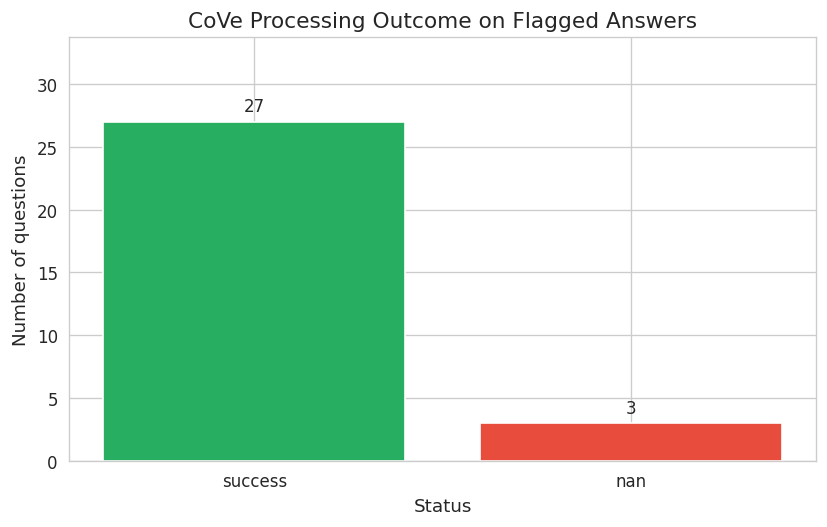

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
status_counts = df['cove_status'].value_counts(dropna=False)

plt.figure(figsize=(7, 4.5))
bars = plt.bar(status_counts.index.astype(str), status_counts.values,
               color=['#27ae60', '#e74c3c', '#95a5a6'], edgecolor='white')
plt.title('CoVe Processing Outcome on Flagged Answers', fontsize=13)
plt.ylabel('Number of questions', fontsize=11)
plt.xlabel('Status', fontsize=11)
plt.ylim(0, max(status_counts)*1.25)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval),
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('fig_3_cove_status.png', dpi=180, bbox_inches='tight')
plt.show()
files.download('fig_3_cove_status.png')

In [33]:
print("\nRandom before/after examples (successful CoVe only):")
examples = df[df['cove_status'] == 'success'].sample(n=6, random_state=42)

for i, row in examples.iterrows():
    print(f"\n {row['qid']}")
    print(f"Question: {row['question'][:120]}{'...' if len(row['question']) > 120 else ''}")
    print(f"\nBaseline:\n{row['generated_answer'][:350]}{'...' if len(row['generated_answer']) > 350 else ''}")
    print(f"\nCoVe version:\n{row['cove_final_answer'][:600]}{'...' if len(row['cove_final_answer']) > 600 else ''}")
    print("└──────────────────────────────────────────────────────────────┘")


Random before/after examples (successful CoVe only):

 q10
Question: Write a function to calculate the sum of all numbers in a list, e.g. [1, 2, 3] -> 6

Baseline:
def sum_list(nums):
  return sum(nums)

CoVe version:
```python
def sum_list(nums):
    if not isinstance(nums, list):
        raise ValueError("Input must be a list")
    numeric_list = [x for x in nums if isinstance(x, (int, float))]
    try:
        return sum(numeric_list)
    except OverflowError:
        raise ValueError("Input list contains very large numbers")
```
└──────────────────────────────────────────────────────────────┘

 q15
Question: What is the purpose of a package manager like npm or pip, e.g. npm install express

Baseline:
package manager installs and manages dependencies

CoVe version:
```python
import subprocess
import sys

def install_package(package_name):
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
    except subprocess.CalledProcessError as e:
   

/tmp/ipython-input-938340166.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


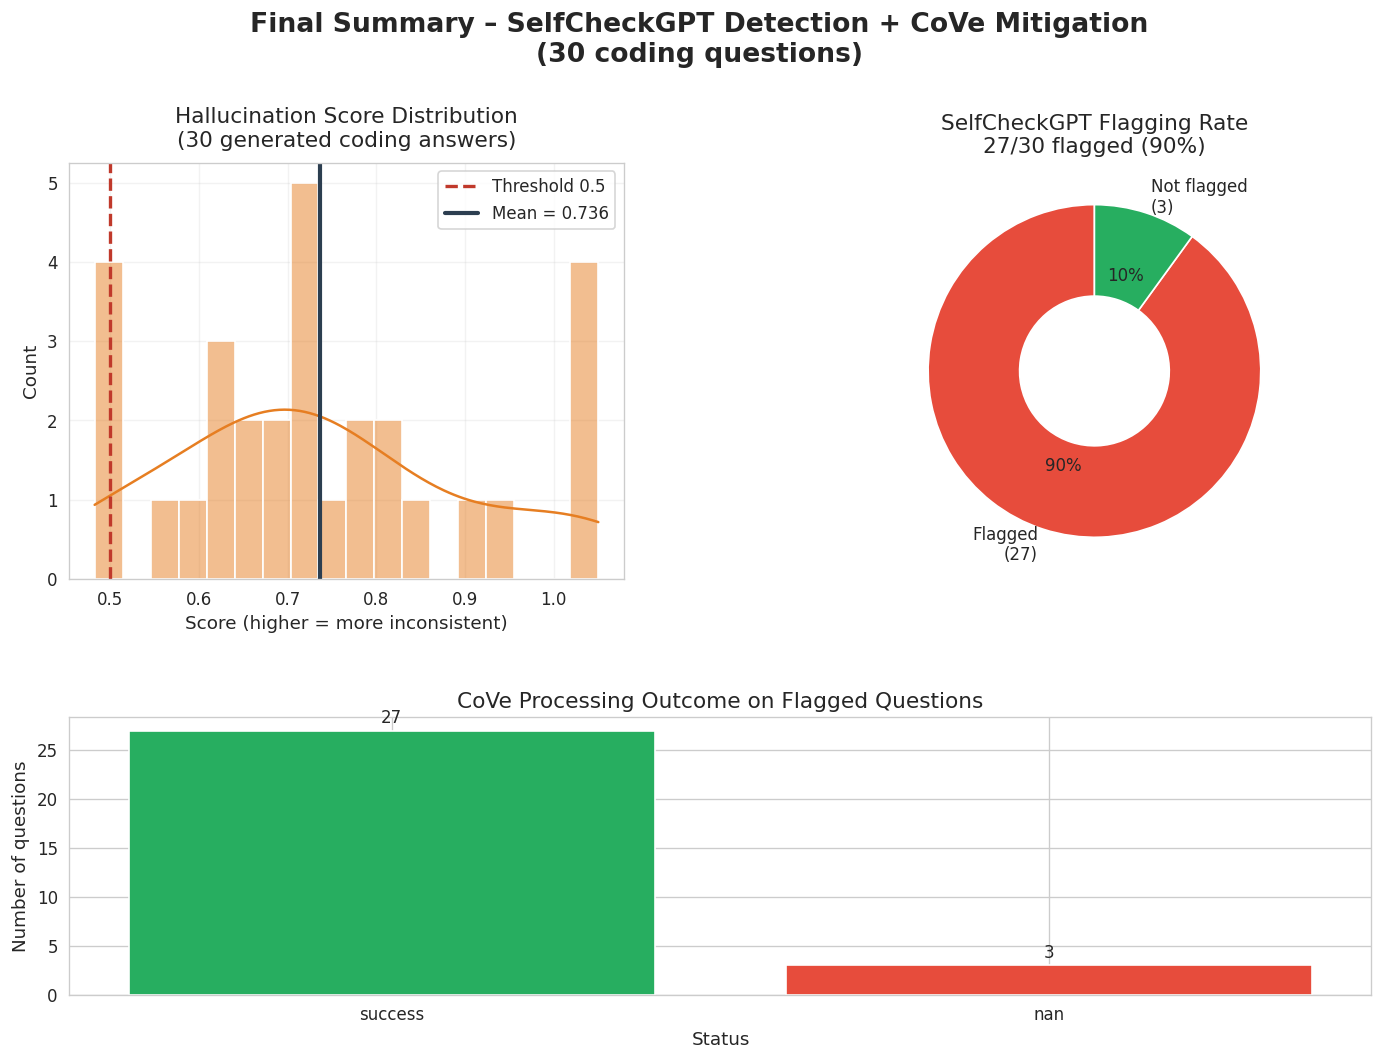

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(14, 9))
gs = GridSpec(2, 2, figure=fig, height_ratios=[3, 2], wspace=0.35, hspace=0.4)

# A: Histogram of hallucination scores (top-left, larger)
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(df['selfcheck_halluc_score'].dropna(), bins=18, kde=True,
             color='#e67e22', edgecolor='white', ax=ax1)
ax1.axvline(0.5, color='#c0392b', ls='--', lw=2, label='Threshold 0.5')
ax1.axvline(df['selfcheck_halluc_score'].mean(), color='#2c3e50', ls='-', lw=2.5,
            label=f'Mean = {df["selfcheck_halluc_score"].mean():.3f}')
ax1.set_title('Hallucination Score Distribution\n(30 generated coding answers)', fontsize=13, pad=10)
ax1.set_xlabel('Score (higher = more inconsistent)', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.25)

# B: Flagging pie (top-right)
ax2 = fig.add_subplot(gs[0, 1])
flagged = df['is_flagged'].sum()
sizes = [flagged, len(df) - flagged]
labels = [f'Flagged\n({flagged})', f'Not flagged\n({len(df)-flagged})']
colors = ['#e74c3c', '#27ae60']
w, t, at = ax2.pie(sizes, labels=labels, autopct='%1.0f%%', startangle=90,
                   colors=colors, wedgeprops=dict(width=0.55, edgecolor='w'))
ax2.set_title(f'SelfCheckGPT Flagging Rate\n{flagged}/{len(df)} flagged ({flagged/len(df)*100:.0f}%)', fontsize=13)

# C: CoVe status bar (bottom, spans both columns)
ax3 = fig.add_subplot(gs[1, :])
status = df['cove_status'].value_counts(dropna=False)
bars = ax3.bar(status.index.astype(str), status.values,
               color=['#27ae60', '#e74c3c', '#95a5a6'], edgecolor='white')
ax3.set_title('CoVe Processing Outcome on Flagged Questions', fontsize=13)
ax3.set_ylabel('Number of questions', fontsize=11)
ax3.set_xlabel('Status', fontsize=11)

for bar in bars:
    y = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, y + 0.4, int(y),
             ha='center', va='bottom', fontsize=10)

plt.suptitle('Final Summary – SelfCheckGPT Detection + CoVe Mitigation\n'
             '(30 coding questions)', fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('final_combined_figure.png', dpi=200, bbox_inches='tight')
plt.show()
files.download('final_combined_figure.png')

In [35]:
summary = pd.DataFrame({
    'Metric': [
        'Total questions',
        'Flagged by SelfCheckGPT',
        'Flagging rate',
        'Mean hallucination score',
        'Median hallucination score',
        'CoVe success rate (on flagged)',
        'Most common CoVe improvement'
    ],
    'Value': [
        len(df),
        df['is_flagged'].sum(),
        f"{df['is_flagged'].mean()*100:.1f}%",
        f"{df['selfcheck_halluc_score'].mean():.3f}",
        f"{df['selfcheck_halluc_score'].median():.3f}",
        f"{(df['cove_status'] == 'success').mean()*100:.1f}%",
        "Added type checks, input validation, error handling"
    ]
})

print("\nFinal Summary Table:")
display(summary.style.set_properties(**{'text-align': 'left'}).set_table_styles([
    {'selector': 'th', 'props': [('font-weight', 'bold'), ('background-color', '#ecf0f1')]}
]))


Final Summary Table:


,Metric,Value
0,Total questions,30
1,Flagged by SelfCheckGPT,27
2,Flagging rate,90.0%
3,Mean hallucination score,0.736
4,Median hallucination score,0.719
5,CoVe success rate (on flagged),90.0%
6,Most common CoVe improvement,"Added type checks, input validation, error handling"


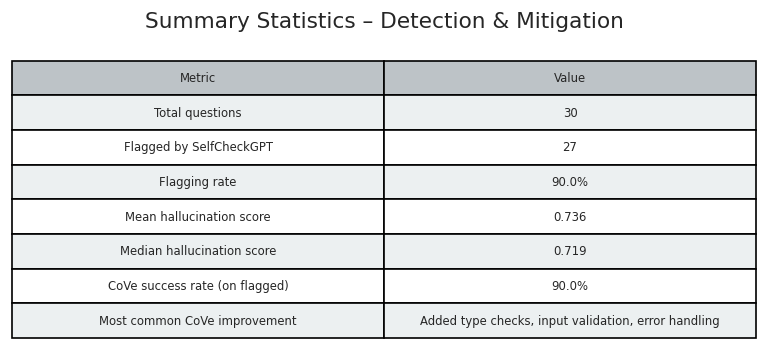

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
from matplotlib.table import Table

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')
tbl = Table(ax, bbox=[0, 0, 1, 1])

nrows, ncols = summary.shape
width, height = 1.0 / ncols, 1.0 / (nrows + 1)

# Header
for j, col in enumerate(summary.columns):
    tbl.add_cell(0, j, width, height, text=col, loc='center',
                 facecolor='#bdc3c7', edgecolor='black')

# Data rows
for i, (_, row) in enumerate(summary.iterrows(), 1):
    for j, val in enumerate(row):
        tbl.add_cell(i, j, width, height, text=str(val), loc='center',
                     facecolor='#ecf0f1' if i % 2 else 'white', edgecolor='black')

ax.add_table(tbl)
plt.title("Summary Statistics – Detection & Mitigation", fontsize=13, pad=20)
plt.savefig('summary_table.png', dpi=200, bbox_inches='tight')
plt.show()
files.download('summary_table.png')